# Week 5 — Optimization Strategies
## What optimizer.step() Actually Does

**IIT Madras · Wadhwani School of AI**

---

**Session Plan (60 min):**
1. GD Variants (~12 min) — Batch vs Stochastic vs Mini-batch, learning rate sensitivity
2. Optimizer Showdown (~15 min) — SGD → Momentum → Adam on Rosenbrock surface + neural net
3. PyTorch Mapping (~8 min) — Custom implementations vs torch.optim
4. Q&A (~10 min)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import time

np.random.seed(42)
torch.manual_seed(42)
print(f"PyTorch: {torch.__version__}")

PyTorch: 2.10.0+cpu


---
# Part 1: Gradient Descent Variants (~12 min)

Every week you've written `optimizer.step()`. Under the hood, it's computing: **θ = θ − lr × ∇L(θ)**. The difference between GD variants is how many samples you use to estimate ∇L.

### 1.1 Synthetic Data

Simple linear regression: y = 3.5x + 2.0 + noise. We know the answer, so we can watch each optimizer find it.

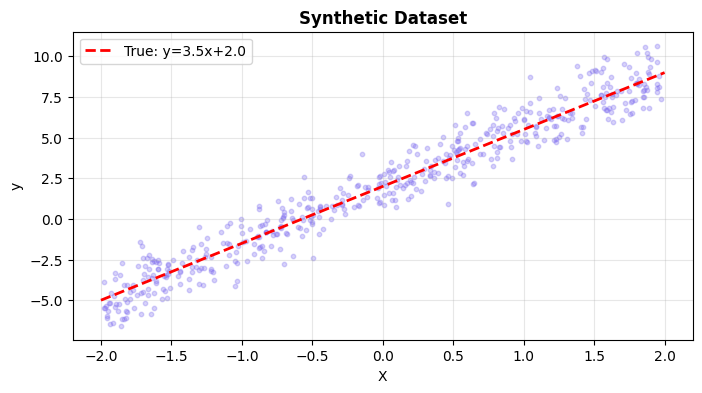

In [ ]:
# Ground truth: y = 3.5x + 2.0
TRUE_W, TRUE_B = 3.5, 2.0
N = 500

X = np.random.uniform(-2, 2, N)
y = TRUE_W * X + TRUE_B + np.random.normal(0, 1.0, N)

plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.3, s=10, color='#7C6AEF')
plt.plot([-2, 2], [TRUE_W*-2+TRUE_B, TRUE_W*2+TRUE_B], 'r--', linewidth=2, label=f'True: y={TRUE_W}x+{TRUE_B}')
plt.xlabel('X'); plt.ylabel('y')
plt.title('Synthetic Dataset', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

### 1.2 Three GD Variants — From Scratch

Same update rule, different batch sizes. Watch how the loss curves differ.

In [ ]:
def compute_loss(X, y, w, b):
    """MSE loss."""
    return np.mean((y - (w * X + b)) ** 2)

def compute_gradients(X, y, w, b):
    """Gradients of MSE w.r.t. w and b."""
    n = len(X)
    error = (w * X + b) - y
    dw = (2/n) * np.sum(error * X)
    db = (2/n) * np.sum(error)
    return dw, db

def gradient_descent(X, y, lr=0.01, epochs=100, batch_size=None, name='GD'):
    """Unified GD: batch_size=None → full batch, =1 → SGD, else mini-batch."""
    w, b = 0.0, 0.0
    losses = []
    n = len(X)

    for epoch in range(epochs):
        if batch_size is None:  # Batch GD — use ALL data
            dw, db = compute_gradients(X, y, w, b)
        else:
            # Sample a batch
            idx = np.random.choice(n, batch_size, replace=False)
            dw, db = compute_gradients(X[idx], y[idx], w, b)

        w -= lr * dw  # θ = θ − lr × ∇L
        b -= lr * db

        losses.append(compute_loss(X, y, w, b))

    return {'w': w, 'b': b, 'losses': losses, 'name': name}

# Run all three
EPOCHS = 100
LR = 0.05

bgd = gradient_descent(X, y, lr=LR, epochs=EPOCHS, batch_size=None, name='Batch GD (all 500)')
sgd = gradient_descent(X, y, lr=LR, epochs=EPOCHS, batch_size=1, name='SGD (1 sample)')
mbgd = gradient_descent(X, y, lr=LR, epochs=EPOCHS, batch_size=32, name='Mini-Batch GD (32)')

print(f"{'Method':<25} {'Final Loss':>12} {'w':>8} {'b':>8}  (true: w={TRUE_W}, b={TRUE_B})")
print('=' * 65)
for r in [bgd, sgd, mbgd]:
    print(f"{r['name']:<25} {r['losses'][-1]:>12.4f} {r['w']:>8.3f} {r['b']:>8.3f}")

Method                      Final Loss        w        b  (true: w=3.5, b=2.0)
Batch GD (all 500)              1.0074    3.557    2.008
SGD (1 sample)                  1.3212    3.950    2.316
Mini-Batch GD (32)              1.0151    3.626    1.976


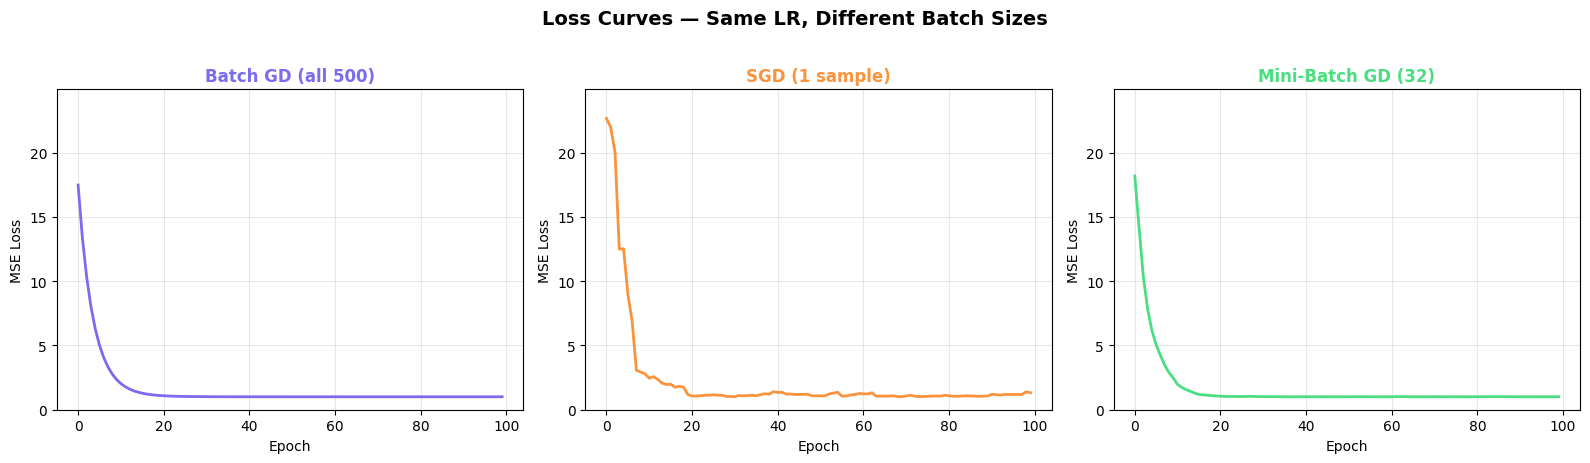

Batch GD: smooth but one step = one pass over ALL data
SGD: noisy but each step only needs 1 sample
Mini-batch: best of both — smooth enough, GPU-parallelizable


In [ ]:
# Plot convergence comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = ['#7C6AEF', '#FB923C', '#4ADE80']

for ax, result, color in zip(axes, [bgd, sgd, mbgd], colors):
    ax.plot(result['losses'], color=color, linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(result['name'], fontweight='bold', color=color)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, max(bgd['losses'][0], sgd['losses'][0]) * 1.1)

fig.suptitle('Loss Curves — Same LR, Different Batch Sizes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Batch GD: smooth but one step = one pass over ALL data")
print("SGD: noisy but each step only needs 1 sample")
print("Mini-batch: best of both — smooth enough, GPU-parallelizable")

### 1.3 Learning Rate Sensitivity

The learning rate is the single most important hyperparameter. Too small = slow. Too large = diverges.

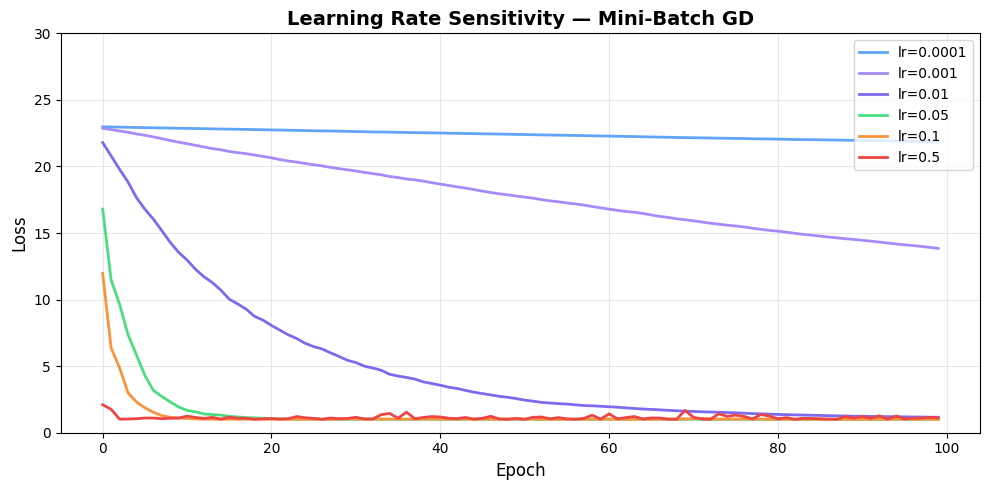

lr=0.0001: barely moves
lr=0.05:   converges nicely
lr=0.5:    diverges — loss explodes

This is why Adam (adaptive LR) is so popular — it adjusts per-parameter.


In [ ]:
lrs = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5]
lr_colors = ['#60A5FA', '#A78BFA', '#7C6AEF', '#4ADE80', '#FB923C', '#EF4444']

fig, ax = plt.subplots(figsize=(10, 5))

for lr, color in zip(lrs, lr_colors):
    result = gradient_descent(X, y, lr=lr, epochs=100, batch_size=32, name=f'lr={lr}')
    losses = np.clip(result['losses'], 0, 50)  # Clip for display
    ax.plot(losses, label=f'lr={lr}', color=color, linewidth=2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Learning Rate Sensitivity — Mini-Batch GD', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

print("lr=0.0001: barely moves")
print("lr=0.05:   converges nicely")
print("lr=0.5:    diverges — loss explodes")
print("\nThis is why Adam (adaptive LR) is so popular — it adjusts per-parameter.")

---
# Part 2: Optimizer Showdown (~15 min)

SGD gets stuck. Momentum helps. Adam adapts. Let's see this on a challenging optimization surface.

### 2.1 The Rosenbrock Function

A classic test surface with a narrow, curved valley. Minimum at (1, 1). Optimizers that only follow the gradient get stuck oscillating across the valley.

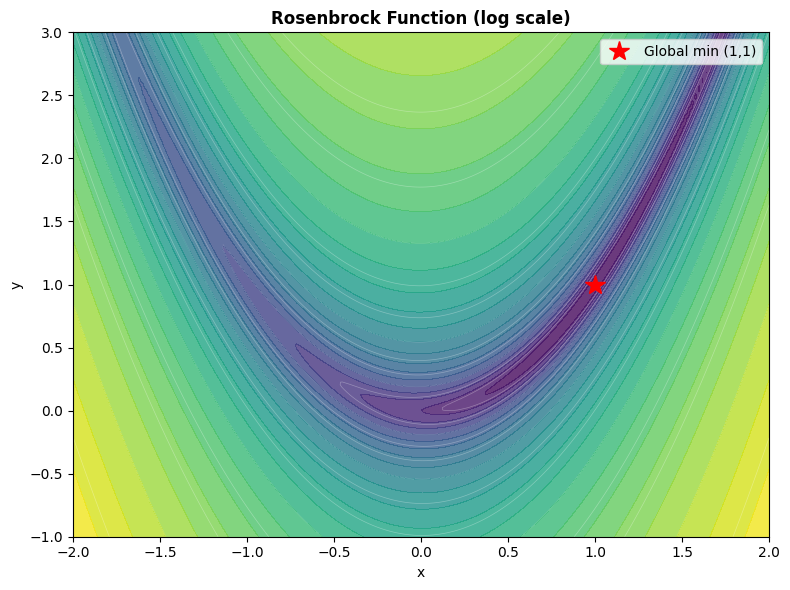

The narrow valley makes this hard for basic SGD.
Gradient across the valley is large. Along the valley, it's tiny.


In [ ]:
def rosenbrock(x, y):
    """f(x,y) = (1-x)² + 100(y-x²)². Minimum at (1,1)."""
    return (1 - x)**2 + 100 * (y - x**2)**2

# Visualize the surface
xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-1, 3, 200))
zz = rosenbrock(xx, yy)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, np.log10(zz + 1), levels=30, cmap='viridis', alpha=0.8)
ax.contour(xx, yy, np.log10(zz + 1), levels=15, colors='white', linewidths=0.5, alpha=0.3)
ax.plot(1, 1, 'r*', markersize=15, label='Global min (1,1)')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Rosenbrock Function (log scale)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("The narrow valley makes this hard for basic SGD.")
print("Gradient across the valley is large. Along the valley, it's tiny.")

### 2.2 Optimizer Trajectories on Rosenbrock

Starting from the same point, watch how different optimizers navigate the surface.

In [ ]:
def optimize_rosenbrock(optimizer_class, lr, n_steps=300, **kwargs):
    """Run a PyTorch optimizer on the Rosenbrock function."""
    # Start at (-1.5, 2.5)
    x = torch.tensor([-1.5], requires_grad=True, dtype=torch.float32)
    y_param = torch.tensor([2.5], requires_grad=True, dtype=torch.float32)

    opt = optimizer_class([x, y_param], lr=lr, **kwargs)

    trajectory = [(x.item(), y_param.item())]
    losses = []

    for _ in range(n_steps):
        opt.zero_grad()
        loss = (1 - x)**2 + 100 * (y_param - x**2)**2
        loss.backward()
        opt.step()

        trajectory.append((x.item(), y_param.item()))
        losses.append(loss.item())

    return np.array(trajectory), losses

# Run optimizers
N_STEPS = 500

traj_sgd, loss_sgd = optimize_rosenbrock(optim.SGD, lr=0.001, n_steps=N_STEPS)
traj_mom, loss_mom = optimize_rosenbrock(optim.SGD, lr=0.001, n_steps=N_STEPS, momentum=0.9)
traj_rmsp, loss_rmsp = optimize_rosenbrock(optim.RMSprop, lr=0.001, n_steps=N_STEPS)
traj_adam, loss_adam = optimize_rosenbrock(optim.Adam, lr=0.01, n_steps=N_STEPS)

print(f"{'Optimizer':<15} {'Final Loss':>12} {'Final (x,y)':>20}  (target: 1.0, 1.0)")
print('=' * 55)
for name, traj, loss in [
    ('SGD', traj_sgd, loss_sgd),
    ('Momentum', traj_mom, loss_mom),
    ('RMSProp', traj_rmsp, loss_rmsp),
    ('Adam', traj_adam, loss_adam),
]:
    print(f"{name:<15} {loss[-1]:>12.4f} {f'({traj[-1,0]:.3f}, {traj[-1,1]:.3f})':>20}")

Optimizer         Final Loss          Final (x,y)  (target: 1.0, 1.0)
SGD                   4.8787      (-1.207, 1.464)
Momentum              0.0062       (0.922, 0.849)
RMSProp               6.2156      (-1.492, 2.233)
Adam                  4.8350      (-1.197, 1.438)


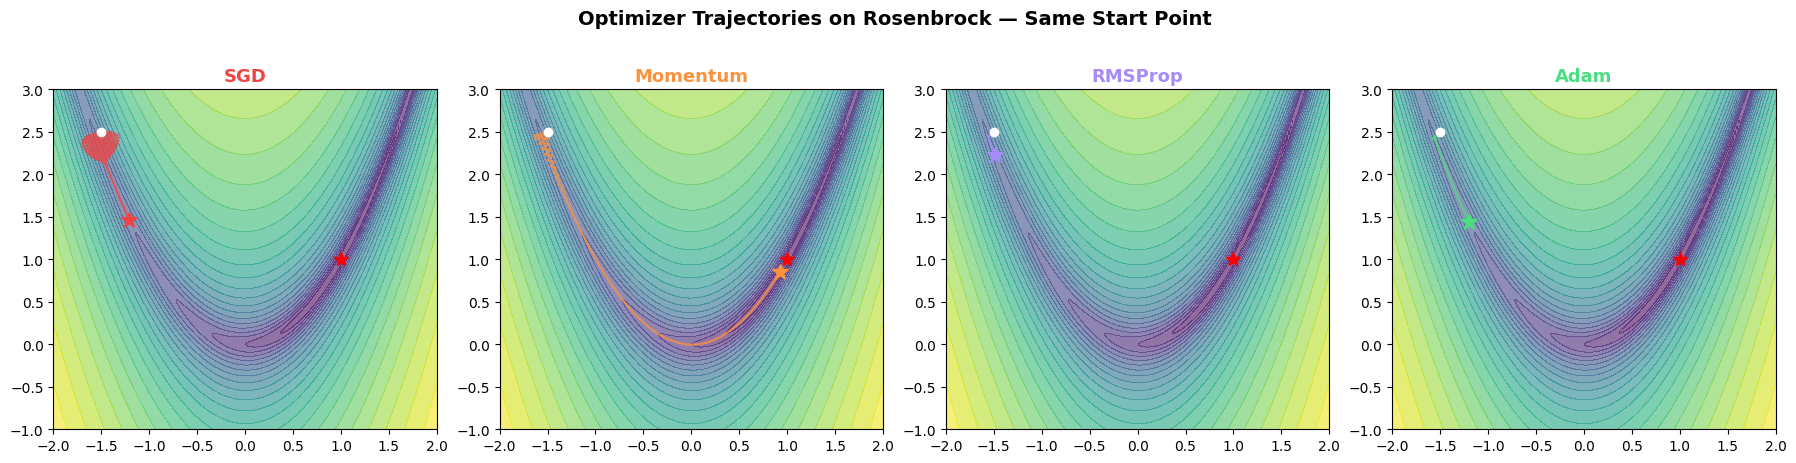

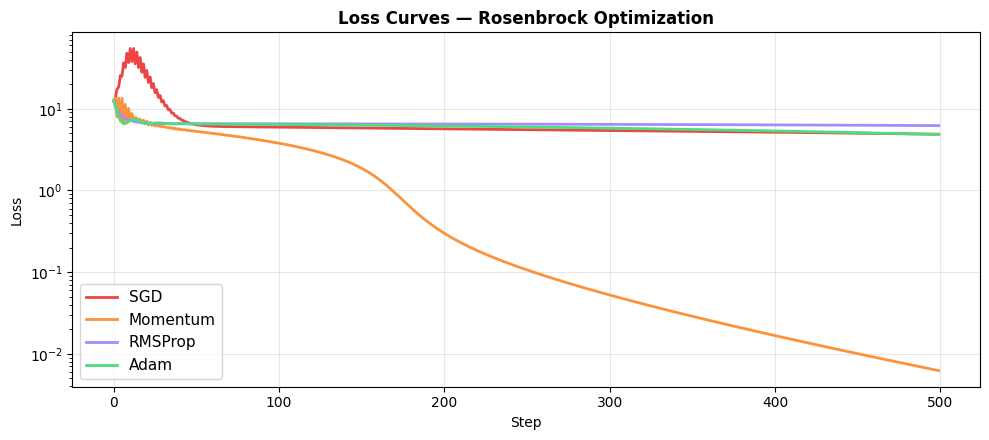

SGD: stuck oscillating. Momentum: overshoots but recovers.
RMSProp: adaptive steps help. Adam: fastest to the minimum.


In [ ]:
# Plot trajectories
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

configs = [
    ('SGD', traj_sgd, '#EF4444'),
    ('Momentum', traj_mom, '#FB923C'),
    ('RMSProp', traj_rmsp, '#A78BFA'),
    ('Adam', traj_adam, '#4ADE80'),
]

for ax, (name, traj, color) in zip(axes, configs):
    ax.contourf(xx, yy, np.log10(zz + 1), levels=30, cmap='viridis', alpha=0.6)
    ax.plot(traj[:, 0], traj[:, 1], '-', color=color, linewidth=1.5, alpha=0.8)
    ax.plot(traj[0, 0], traj[0, 1], 'wo', markersize=6)  # Start
    ax.plot(traj[-1, 0], traj[-1, 1], color=color, marker='*', markersize=12)  # End
    ax.plot(1, 1, 'r*', markersize=10)  # Target
    ax.set_title(name, fontweight='bold', color=color, fontsize=13)
    ax.set_xlim(-2, 2); ax.set_ylim(-1, 3)

fig.suptitle('Optimizer Trajectories on Rosenbrock — Same Start Point',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Loss curves
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, losses, color in [
    ('SGD', loss_sgd, '#EF4444'),
    ('Momentum', loss_mom, '#FB923C'),
    ('RMSProp', loss_rmsp, '#A78BFA'),
    ('Adam', loss_adam, '#4ADE80'),
]:
    ax.plot(np.clip(losses, 0, 1000), label=name, color=color, linewidth=2)

ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('Loss Curves — Rosenbrock Optimization', fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print("SGD: stuck oscillating. Momentum: overshoots but recovers.")
print("RMSProp: adaptive steps help. Adam: fastest to the minimum.")

### 2.3 Neural Network Training Comparison

Now the real test — train the same neural network with different optimizers on a non-linear classification problem.

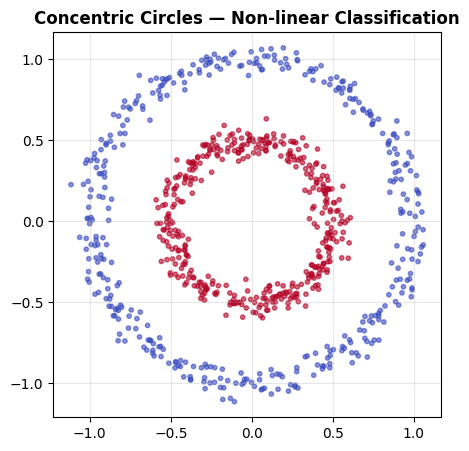

A simple MLP can solve this, but optimizer choice affects convergence speed.


In [ ]:
from sklearn.datasets import make_circles

# Create concentric circles dataset
X_data, y_data = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

# Split
X_train, X_test = X_data[:800], X_data[800:]
y_train, y_test = y_data[:800], y_data[800:]

# To tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

plt.figure(figsize=(5, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=10, alpha=0.6)
plt.title('Concentric Circles — Non-linear Classification', fontweight='bold')
plt.axis('equal'); plt.grid(True, alpha=0.3)
plt.show()
print("A simple MLP can solve this, but optimizer choice affects convergence speed.")

In [ ]:
class CircleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_with_optimizer(opt_class, opt_kwargs, n_epochs=100):
    """Train CircleNet and return loss history."""
    torch.manual_seed(42)
    model = CircleNet()
    optimizer = opt_class(model.parameters(), **opt_kwargs)
    loss_fn = nn.BCEWithLogitsLoss()

    train_losses, test_accs = [], []
    for epoch in range(n_epochs):
        model.train()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.inference_mode():
            test_pred = (torch.sigmoid(model(X_test_t)) >= 0.5).float()
            acc = (test_pred == y_test_t).float().mean().item()
            test_accs.append(acc)

    return train_losses, test_accs


# Compare optimizers
optimizers = {
    'SGD (lr=0.01)':       (optim.SGD,     {'lr': 0.01}),
    'SGD + Momentum':      (optim.SGD,     {'lr': 0.01, 'momentum': 0.9}),
    'RMSProp':             (optim.RMSprop, {'lr': 0.001}),
    'Adam':                (optim.Adam,    {'lr': 0.001}),
    'AdamW':               (optim.AdamW,   {'lr': 0.001, 'weight_decay': 0.01}),
}

N_EPOCHS = 200
results = {}

for name, (opt_cls, opt_kw) in optimizers.items():
    losses, accs = train_with_optimizer(opt_cls, opt_kw, n_epochs=N_EPOCHS)
    results[name] = {'losses': losses, 'accs': accs}
    print(f"{name:20s} → Final acc: {accs[-1]:.1%}, Final loss: {losses[-1]:.4f}")

SGD (lr=0.01)        → Final acc: 64.5%, Final loss: 0.6876
SGD + Momentum       → Final acc: 97.5%, Final loss: 0.6261
RMSProp              → Final acc: 100.0%, Final loss: 0.1151
Adam                 → Final acc: 100.0%, Final loss: 0.2797
AdamW                → Final acc: 100.0%, Final loss: 0.2805


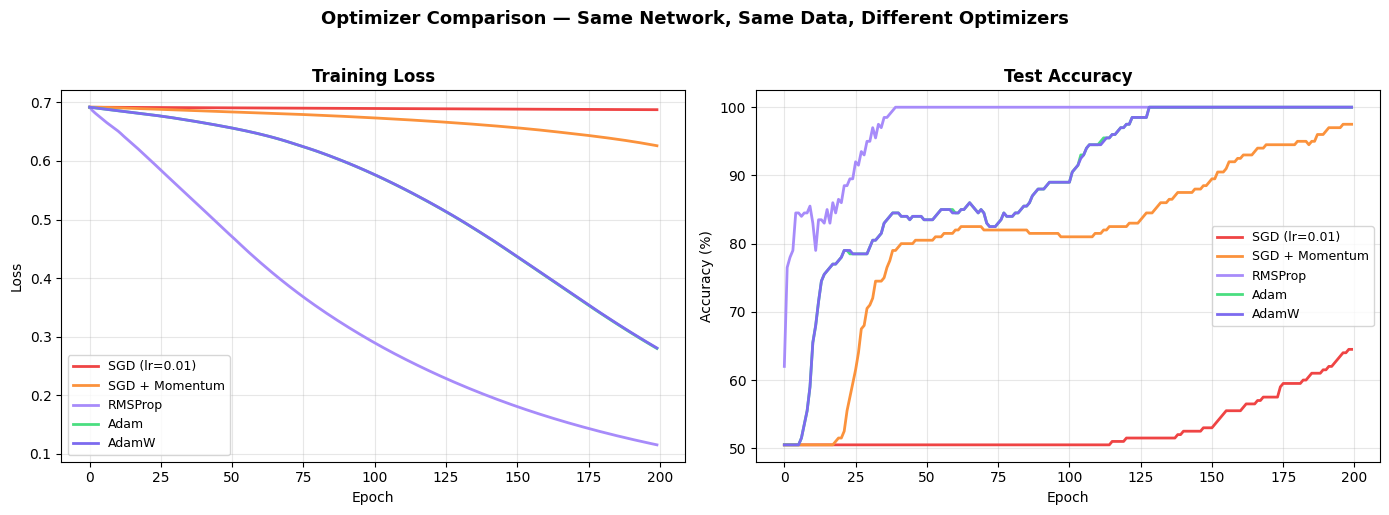

SGD is slowest. Momentum helps a lot. Adam/AdamW converge fastest.
This is why Adam has been our default in weeks 1–4.


In [ ]:
opt_colors = ['#EF4444', '#FB923C', '#A78BFA', '#4ADE80', '#7C6AEF']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, res), color in zip(results.items(), opt_colors):
    axes[0].plot(res['losses'], label=name, color=color, linewidth=2)
    axes[1].plot([a*100 for a in res['accs']], label=name, color=color, linewidth=2)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

fig.suptitle('Optimizer Comparison — Same Network, Same Data, Different Optimizers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("SGD is slowest. Momentum helps a lot. Adam/AdamW converge fastest.")
print("This is why Adam has been our default in weeks 1–4.")

---
# Part 3: PyTorch Mapping (~8 min)

Let's build Adam from scratch so you see exactly what `optim.Adam` does inside `step()`. Then compare to PyTorch's version.

### 3.1 Adam From Scratch

Adam combines two ideas: **momentum** (average of past gradients) and **adaptive LR** (average of past squared gradients), with bias correction for early steps.

In [ ]:
class AdamFromScratch:
    """Adam optimizer — implemented from the paper."""
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1   # Momentum decay
        self.beta2 = beta2   # RMSProp decay
        self.eps = eps
        self.t = 0
        # State: per-parameter momentum and velocity
        self.m = [torch.zeros_like(p) for p in self.params]  # 1st moment (mean)
        self.v = [torch.zeros_like(p) for p in self.params]  # 2nd moment (variance)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue
            g = p.grad.data

            # Update biased first moment (momentum)
            self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g

            # Update biased second moment (RMSProp)
            self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * g**2

            # Bias correction (important for early steps)
            m_hat = self.m[i] / (1 - self.beta1**self.t)
            v_hat = self.v[i] / (1 - self.beta2**self.t)

            # Update: θ = θ − lr × m_hat / (√v_hat + ε)
            p.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

print("Adam in ~20 lines of code.")
print("PyTorch's optim.Adam does the same thing, but optimized in C++.")

Adam in ~20 lines of code.
PyTorch's optim.Adam does the same thing, but optimized in C++.


### 3.2 Custom vs PyTorch — Same Results

Train the same network with our from-scratch Adam and PyTorch's Adam. They should produce nearly identical loss curves.

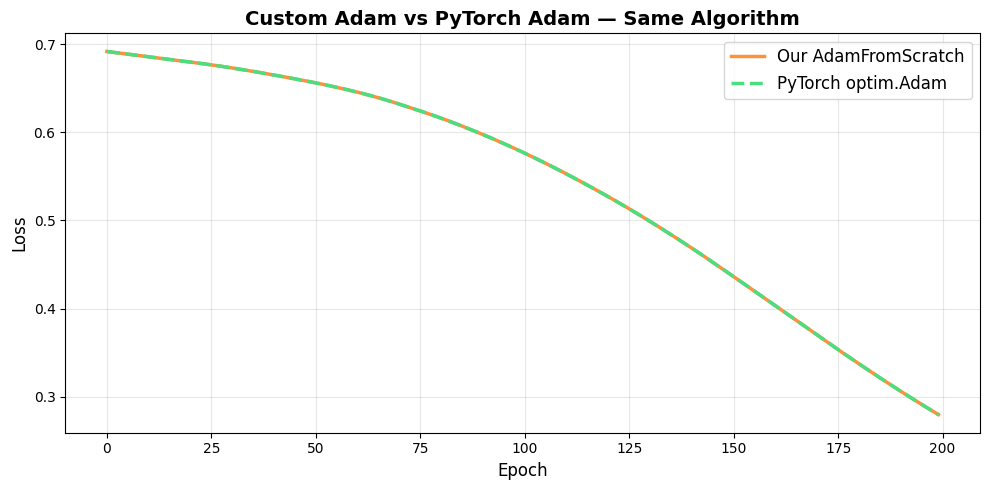

Custom final loss:  0.2797
PyTorch final loss: 0.2797

Same algorithm. Same result. PyTorch just saves you the implementation.


In [ ]:
def train_custom_adam(n_epochs=200):
    torch.manual_seed(42)
    model = CircleNet()
    optimizer = AdamFromScratch(model.parameters(), lr=0.001)
    loss_fn = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(n_epochs):
        model.train()
        pred = model(X_train_t)
        loss = loss_fn(pred, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

custom_losses = train_custom_adam(200)
pytorch_losses = results['Adam']['losses']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(custom_losses, label='Our AdamFromScratch', color='#FB923C', linewidth=2.5)
ax.plot(pytorch_losses, label='PyTorch optim.Adam', color='#4ADE80', linewidth=2.5, linestyle='--')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Custom Adam vs PyTorch Adam — Same Algorithm', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Custom final loss:  {custom_losses[-1]:.4f}")
print(f"PyTorch final loss: {pytorch_losses[-1]:.4f}")
print(f"\nSame algorithm. Same result. PyTorch just saves you the implementation.")

---
# Recap

### 1. GD Variants = How Many Samples Per Step
- **Batch GD**: all data → smooth but slow
- **SGD**: 1 sample → fast but noisy
- **Mini-batch**: 32–256 → the default (what DataLoader gives you)

### 2. Optimizer Evolution
- **SGD**: simple but gets stuck in ravines
- **Momentum**: accumulates velocity, rolls through ravines
- **RMSProp**: per-parameter adaptive learning rate
- **Adam**: Momentum + RMSProp + bias correction → your default
- **AdamW**: Adam + proper weight decay → state of the art

### 3. The 5-Step Loop — Now Fully Understood
```python
pred = model(X)           # Forward pass
loss = loss_fn(pred, y)   # Compute loss L(θ)
optimizer.zero_grad()     # Clear old gradients
loss.backward()           # Compute ∇L(θ) — the gradient
optimizer.step()          # θ = θ − lr × f(∇L) — the update rule
```
Now you know exactly what `step()` computes inside.

### 4. Practical Defaults
- **Start with**: `optim.Adam(model.parameters(), lr=0.001)`
- **For better generalization**: `optim.AdamW(lr=0.001, weight_decay=0.01)`
- **If overfitting**: try SGD + Momentum (better generalization, slower convergence)

---
*Questions?*